In [82]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import os
from pyphoenix import pyphoenix

# System Parameters
grid_size = 128                 # Grid Size, int this case 200x200
x_max = 20                      # mum; Maximum Distance, meaning the grid will be from -10mum to 10mum
effective_mass = 0.5*5.864E-4   # kg; Effective Mass of the electron, scaled
gamma_c = 0.16                  # Polariton Loss Rate
gamma_r = 1.5 * gamma_c         # Reservoir Loss Rate
R = 0.01                        # Condensation Rate
g_c = 6E-6                      # Polariton-Polariton Coupling
g_r = 2*g_c                     # Polariton-Reservoir Coupling
t_end = 3000                    # ps; End time of the simulation
sample_after = 1999.99          # ps; Time to start sampling the data
window_percent = 0.5            # Inner percentage of the grid window to sample
sampling_rate = 0.5             # ps; Sampling rate of the simulation

# Additional Parameters not required by PHOENIX:
hbar = 6.582119569E-4
dx = x_max/grid_size

# Grid Window
grid_start = int(grid_size/2 - grid_size/2*window_percent)
grid_width = int(grid_size*window_percent)

# Matrix Generation

While PHOENIX can also generate spacial shapes via its envelope syntax, it is usually beneficial to pre-generate all required inputs. This way, we can plot and verify the inputs beforehand.

We generate an X-Y Meshgrid using numpy, fill the pump and potential matrices and plot them. Because we want to vary the first pump amplitude, we create a lambda for the pump creation.

We also plot the inputs for verification purposes. We can save the matrices row wise, noting that PHOENIX also reads the matrices as row major inputs. 


In [83]:
# X-Y Meshgrid
x = np.linspace(-x_max/2, x_max/2, grid_size, endpoint=False)
y = np.linspace(-x_max/2, x_max/2, grid_size, endpoint=False)
X, Y = np.meshgrid(x, y)

# Helper Function to save the numpy matrices into a format PHOENIX can read
def save_matrix(matrix, filename):
    header = f"SIZE {grid_size} {grid_size} {x_max} {x_max} {dx} {dx} PYTHON-GENERATED"
    # if real matrix
    if np.isrealobj(matrix):
        np.savetxt( filename, matrix, header=header, fmt='%.5f' )
    else:
        np.savetxt( filename, matrix.real, header=header, fmt='%.5f' )

## Pump Generation ##

# Spacing shifts both the pump and the potential wells
spacing = 4.0

# Pump 
pump1_amp = 8.0
pump1_w = 1.0
pump2_amp = 12.0
pump2_w = 1.0

# We create a lambda for the pump because we are going to vary the pump amplitude in the optimization and scanning process
generate_pump = lambda pump_varied: pump_varied*np.exp(-np.sqrt((X+spacing/2)**2 + Y**2) / (pump1_w**2) ) + pump2_amp*np.exp(-np.sqrt( (X-spacing/2)**2 + Y**2 ) / (pump2_w**2) )
pump = generate_pump(pump1_amp)

# Save the pump using X,Y,Re,Im format
save_matrix(pump, "pump_plus.txt")

## Potential Generation ##

potential1_amp = -2E-3
potential1_w = 1.5
potential2_amp = -2.2E-3
potential2_w = 1.5
potential_order = 2

potential = potential1_amp*np.exp(-( ((X+spacing/2)**2 + Y**2)/(potential1_w**2) )**potential_order ) + potential2_amp*np.exp(-( ((X-spacing/2)**2 + Y**2)/(potential2_w**2) )**potential_order)

# Save the potential using X,Y,Re,Im format
save_matrix(potential, "potential_plus.txt")

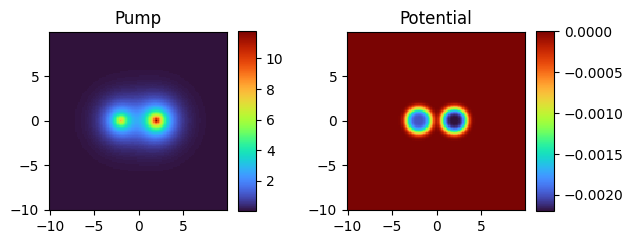

In [84]:
# Plot the pump and potential
fig, (ax1,ax2) = plt.subplots(1,2)
plt_pump = ax1.pcolormesh(X,Y,pump, cmap="turbo")
ax1.set_title("Pump")
plt_pot = ax2.pcolormesh(X,Y,potential, cmap="turbo")
ax2.set_title("Potential")

# Colorbars
fig.colorbar(plt_pump, shrink=0.4, aspect=10)
fig.colorbar(plt_pot, shrink=0.4, aspect=10)
[ax.set_aspect("equal") for ax in (ax1,ax2)]

plt.tight_layout()

# Run a Simulation with PHOENIX

We also plot the test calculation. The density for the given set of parameters should approach zero.

In [85]:
def run(t_max: float = t_end, history: bool = False):
    # define simulation parameters with a dict
    config={
        "N":[grid_size,grid_size],  # Set the grid size in points
        "L":[x_max,x_max],          # Set the grid size in mum
        "meff":effective_mass,      # Set the effective mass
        "tmax":t_max,               # Set the end time  
        "tstep":0.02,               # Set the time step
        "outEvery": sampling_rate,  # Set sample rate 
        "gc":g_c,                   # Set the coupling constants
        "gr":g_r,                   # Set the coupling constants
        "R":R,                      # Set the condensation rate
        "gammaR": gamma_r,          # Set the reservoir loss rate
        "gammaC": gamma_c,          # Set the polariton loss rate
        "boundary": ["periodic","periodic"], # Set periodic boundary conditions in both directions
        "fftEvery": 0.001,         # Set the FFT sample rate
        "fftMask": [1.0,"add",0.2,0.2,0,0,"both",10,"none","gauss+local+noDivide"]
    }
    # Add pump 
    config["pump"]=["load","pump_plus.txt","1","add","both"]
    # Load the pump as the initial state
    eps = 1e-7
    config["initialState"] = ["load", "pump_plus.txt", eps, "add", "both"]
    # Load the pump as the initial reservoir
    config["initialReservoir"]=["load","pump_plus.txt",1,"add","both"]
    # Load the potential
    config["potential"]=["load","potential_plus.txt",1,"add","both"]
    # Set output
    if history:
        config["output"]="wavefunction"
        config["historyMatrix"]=[grid_start,grid_start+grid_width,grid_start,grid_start+grid_width,1] # Add Time Matrix History output
        config["historyTime"]=[sample_after,1]   # Add Time Matrix History output
         
    ph=pyphoenix.pyphoenix(debug=False,precision="fp32",doprint=False)
    ph.run(config)
    return ph
    
ph=run(t_max=5000, history = True)    

### Plotting
PHOENIX saves outputs using one row per line, saving real parts first. This means, for our 200x200 complex matrices, PHOENIX will output a textfile containing a 400x200 (rows,cols) matrix. When loading the real and imaginary parts of the result, we can also calculate the phase using `np.angle`.

In [86]:
import os, glob, re
import numpy as np

res = ph.get_result_path()
files = sorted(glob.glob(os.path.join(res, "**", "wavefunction_plus_*.txt"), recursive=True))

time_re = re.compile(r"wavefunction_plus_([0-9]+(?:\.[0-9]+)?)\.txt$")

times = []
rho_max = []

for f in files:
    m = time_re.search(os.path.basename(f))
    if not m:
        continue
    t = float(m.group(1))

    data = np.loadtxt(f, comments="#")  # shape (2N, N) dla wycinka historyMatrix
    if data.shape[0] % 2 != 0:
        raise ValueError(f"Unexpected rows count in {f}: {data.shape}")

    N = data.shape[0] // 2
    # (opcjonalnie) sanity: jeśli to ma być kwadrat
    # assert data.shape[1] == N, f"Non-square matrix in {f}: {data.shape}"

    re_part = data[:N, :]
    im_part = data[N:, :]
    rho = re_part*re_part + im_part*im_part

    times.append(t)
    rho_max.append(float(rho.max()))

times = np.asarray(times)
rho_max = np.asarray(rho_max)

out_path = os.path.join(res, "rho_max_plus.txt")
np.savetxt(out_path, np.column_stack([times, rho_max]), header="t_ps rho_max", fmt="%.6f %.12e")
print("Saved:", out_path, "points:", len(times))

Saved: /opt/PHOENIX/examples/example_2/phoenix_tmp/phoenix_tmpqnwxjqef/rho_max_plus.txt points: 6001
